In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:

import os
from pathlib import Path

REPO_URL = "https://github.com/yehonatan768/Facial_Recognition.git"   # change
DEST_DIR = Path("/content/Face_Recognition")            # choose folder name

if DEST_DIR.exists():
    print("Repo folder already exists:", DEST_DIR)
else:
    !git clone {REPO_URL} {DEST_DIR}

%cd /content/Face_Recognition
!git status

Cloning into '/content/Face_Recognition'...
remote: Enumerating objects: 302, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 302 (delta 87), reused 89 (delta 72), pack-reused 188 (from 1)
Receiving objects: 100% (302/302), 2.69 MiB | 25.75 MiB/s, done.
Resolving deltas: 100% (166/166), done.
/content/Face_Recognition
On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [ ]:
!git checkout Sprint-3

Branch 'Sprint-3' set up to track remote branch 'Sprint-3' from 'origin'.
Switched to a new branch 'Sprint-3'


In [ ]:
from pathlib import Path
import shutil

ZIP_ON_DRIVE = Path("/content/drive/MyDrive/Facial_Recognition/lfwa.zip")  # change if needed
ZIP_LOCAL = Path("/content/lfwa.zip")

shutil.copy2(ZIP_ON_DRIVE, ZIP_LOCAL)
print("Copied ZIP to local:", ZIP_LOCAL)

Copied ZIP to local: /content/lfwa.zip


In [ ]:
import zipfile
from pathlib import Path
import shutil

ZIP_LOCAL = Path("/content/lfwa.zip")
IMAGES_DIR = Path("/content/Face_Recognition/images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

prefix = "lfw2/lfw2/"

with zipfile.ZipFile(ZIP_LOCAL) as z:
    for member in z.namelist():
        if member.startswith(prefix) and not member.endswith("/"):
            rel = Path(member).parts[len(Path(prefix).parts):]
            out = IMAGES_DIR.joinpath(*rel)

            out.parent.mkdir(parents=True, exist_ok=True)
            with z.open(member) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst)

print("Extracted locally into:", IMAGES_DIR)

Extracted locally into: /content/Face_Recognition/images


In [ ]:
!ls

assets	images	notebooks  README.md  report  requirements.txt	src


In [ ]:
!git pull origin Sprint-3

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 388 bytes | 388.00 KiB/s, done.
From https://github.com/yehonatan768/Facial_Recognition
 * branch            Sprint-3   -> FETCH_HEAD
   907a886..a6ae38c  Sprint-3   -> origin/Sprint-3
Updating 907a886..a6ae38c
Fast-forward
 src/config/config.yaml | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)


Loaded 2200 training pairs


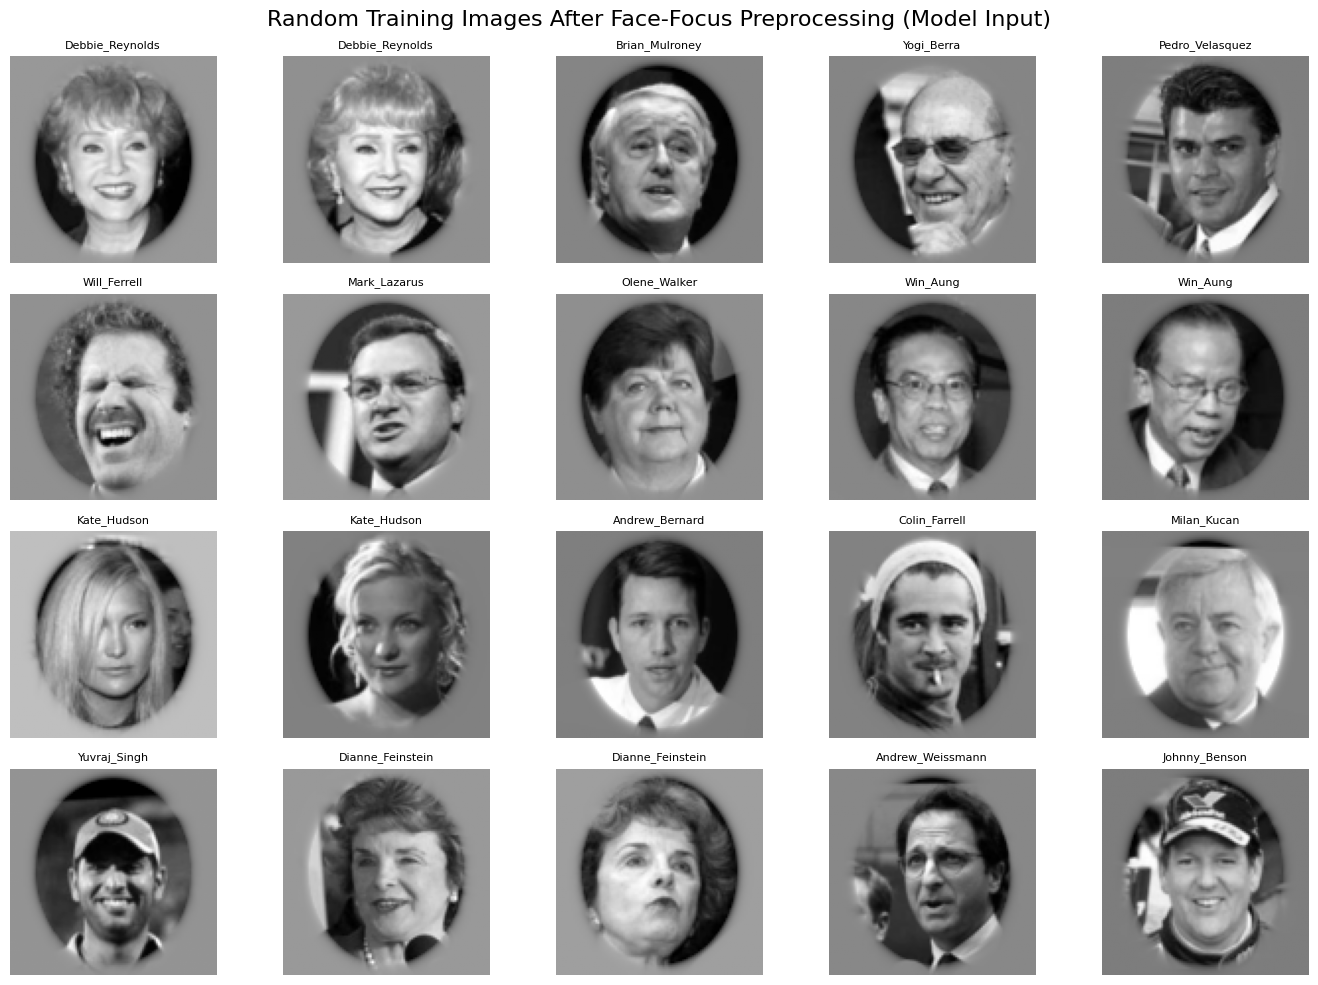

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from src.utils.read_config import read_model_config
from src.data.load_data import load_train_test_pairs
from src.preprocess.preprocess import FaceFocusConfig, build_focus_face_transform


# -------------------------
# Load config
# -------------------------
# If you're running this notebook from repo root, this is fine.
# If not, read_model_config() will still store the resolved project_root for path resolution.
PROJECT_ROOT = Path.cwd().resolve()
CFG_PATH = PROJECT_ROOT / "src" / "config" / "config.yaml"
cfg = read_model_config(CFG_PATH)

# Prefer project_root detected by read_model_config (portable across machines / CWD)
PROJECT_ROOT = Path(cfg.get("paths", {}).get("project_root", PROJECT_ROOT)).resolve()

# -------------------------
# Resolve paths
# -------------------------
paths = cfg["paths"]
images_root = (PROJECT_ROOT / paths["images_root"]).resolve()
pairs_train = (PROJECT_ROOT / paths["pairs_train"]).resolve()
pairs_test = (PROJECT_ROOT / paths["pairs_test"]).resolve()

# -------------------------
# Load pairs
# -------------------------
loaded = load_train_test_pairs(
    train_pairs_path=pairs_train,
    test_pairs_path=pairs_test,
    images_root=images_root,
    ext=cfg.get("data", {}).get("image_ext", ".jpg"),
    strict_exists=True,
)
train_pairs = loaded["train_pairs"]
print(f"Loaded {len(train_pairs)} training pairs")

# -------------------------
# Build transform (face-focus, same parameters as config)
# -------------------------
input_size = int(cfg.get("transform", {}).get("input_size", 105))
mean = float(cfg.get("transform", {}).get("mean", 0.5))
std = float(cfg.get("transform", {}).get("std", 0.5))

focus_cfg = (cfg.get("data", {}) or {}).get("face_focus", {}) or {}

# Use FaceFocusConfig defaults if keys are missing
face_focus = FaceFocusConfig(
    size=int(focus_cfg.get("size", input_size)),
    pre_crop_ratio=float(focus_cfg.get("pre_crop_ratio", 0.90)),
    center=tuple(focus_cfg.get("center", (0.0, 0.0))),
    axes=tuple(focus_cfg.get("axes", (0.75, 0.90))),
    edge_softness=float(focus_cfg.get("edge_softness", 0.08)),
    mask_power=float(focus_cfg.get("mask_power", 2.0)),
    randomize_background=bool(focus_cfg.get("randomize_background", False)),  # False for deterministic view
    background_noise_std=float(focus_cfg.get("background_noise_std", 0.08)),
    jitter_center=float(focus_cfg.get("jitter_center", 0.03)),
    jitter_axes=float(focus_cfg.get("jitter_axes", 0.05)),
    background_fill=float(focus_cfg.get("background_fill", 0.5)),
)

transform = build_focus_face_transform(
    train=False,  # deterministic view in notebook
    cfg=face_focus,
    normalize_mean=mean,
    normalize_std=std,
)

# -------------------------
# Sample 20 random images
# -------------------------
sample_pairs = random.sample(train_pairs, 10)  # 10 pairs -> 20 images
image_paths = []
for p1, p2, *_ in sample_pairs:
    image_paths.append(p1)
    image_paths.append(p2)

# -------------------------
# Plot (after transform)
# -------------------------
fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):
    img_path = Path(img_path)

    pil = Image.open(img_path).convert("RGB")
    x = transform(pil)                 # (1, H, W) normalized
    x_vis = x.squeeze(0).numpy()       # (H, W)

    ax.imshow(x_vis, cmap="gray")
    ax.set_title(img_path.parent.name, fontsize=8)
    ax.axis("off")

plt.suptitle("Random Training Images After Face-Focus Preprocessing (Model Input)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
!git pull origin Sprint-3

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 390 bytes | 390.00 KiB/s, done.
From https://github.com/yehonatan768/Facial_Recognition
 * branch            Sprint-3   -> FETCH_HEAD
   d62f7e7..86e4a02  Sprint-3   -> origin/Sprint-3
Updating d62f7e7..86e4a02
Fast-forward
 src/config/config.yaml | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)


In [ ]:
!python -m src.run.train

2025-12-28 16:17:02 | INFO | train | Device: cuda
2025-12-28 16:17:02 | INFO | train | Cleared previous metrics file: /content/Face_Recognition/outputs/metrics.jsonl
2025-12-28 16:17:02 | INFO | train | Loaded train pairs: 2200
2025-12-28 16:17:02 | INFO | train | Loaded test pairs:  1000
2025-12-28 16:17:02 | INFO | train | Train positives: 1100 | negatives: 1100
2025-12-28 16:17:02 | INFO | train | Test positives:  500 | negatives: 500
2025-12-28 16:17:11 | INFO | train | [Split] train pairs: n=1760 pos_frac=0.509 | val pairs: n=440 pos_frac=0.464 | target_val_pairs=440 target_pos_frac=0.50
2025-12-28 16:17:11 | INFO | train | [Split] train_ids=1840 | val_ids=292 | components=1032
2025-12-28 16:17:12 | INFO | train | Train pairs: 1760 | Val pairs: 440 | Test pairs: 1000
2025-12-28 16:17:12 | INFO | train | epochs=200 batch_size=128 monitor=val_loss mode=min early_stop=True
2025-12-28 16:17:22 | INFO | train | Epoch 001/200 | train_loss=0.694154 val_loss=0.691236 | train_acc=0.4756 va

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

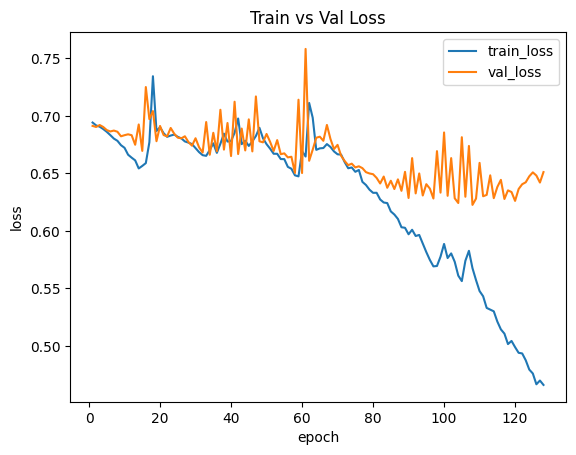

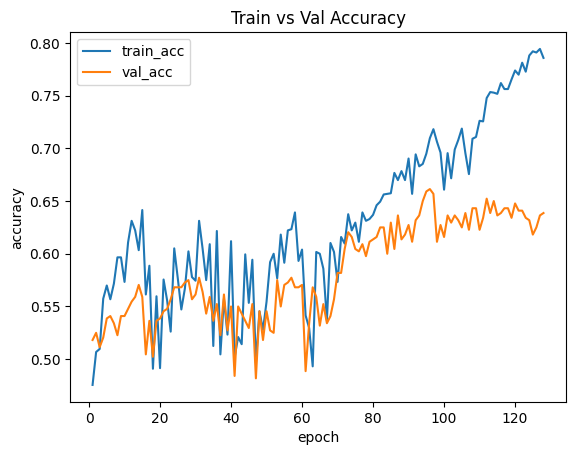

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Point this at your run folder (the same --workdir you used in training)
workdir = Path("outputs")  # change if needed
metrics_path = workdir / "metrics.jsonl"

rows = []
with metrics_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows).sort_values("epoch")

# --- Plot losses together ---
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="train_loss")
plt.plot(df["epoch"], df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Train vs Val Loss")
plt.show()

# --- Plot accuracies together ---
plt.figure()
plt.plot(df["epoch"], df["train_acc"], label="train_acc")
plt.plot(df["epoch"], df["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Train vs Val Accuracy")
plt.show()


In [ ]:
from src.models.siamese import PaperSiameseModel as model

model = model()
print('number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

number of parameters: 38951744
